<a href="https://colab.research.google.com/github/maxpopp8/rush-sportswear-sales-analysis/blob/main/GB885_Final_Project_Popp_M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Final Project
You work as an analyst for RUSH, a globally renowned sportswear and footwear brand known for its innovative designs and performance-oriented products. The company stores its raw sales data as a collection of three tables:
* TABLE_PRODUCTS
* TABLE_RETAILER
* TABLE_SALES

The data includes the number of units sold, the total sales revenue, the location of the sales, the type of product sold, as well as other relevant information. (For data field definitions and explanations, see the data dictionary.) The data is “raw,” meaning it has not been cleaned and probably contains errors that need to be addressed.

The VP of US Sales has tasked you with analyzing sales data for trends and insights that will help company leadership understand the market and identify opportunities for growth. For example, you may want to look for trends or insights in seasonality, retailers, locations, or sales methods. Take the initiative to apply your creativity and curiosity to the data.

In addition, she has asked for you to query the data warehouse to answer the following business questions:
* What product category (product) had the highest sales (in dollars) in 2021
* How much did it sell?
* What state had the highest sales (in dollars) of women's products in 2021, and how much was it?
* What state had the highest sales (in dollars) of men's products in 2021, and how much was it?
* What retailer purchased the most units in 2021? In 2020?


In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Data

In [3]:
# load data into collab notebook
products = pd.read_csv('TABLE_PRODUCTS_885.csv', sep='|')
retailers = pd.read_csv('TABLE_RETAILER_885.csv')
sales = pd.read_csv('TABLE_SALES_885.csv')

# Data Inspection

In [5]:
# inspect the tables

print('Products:')
print(products.shape)

print('n/Retailers:')
print(retailers.shape)

print('n/Sales:')
print(sales.shape)

Products:
(6, 2)
n/Retailers:
(110, 5)
n/Sales:
(9648, 11)


In [6]:
# data preview of products
display(products.head())

,PRODUCT_ID,PRODUCT_NAME
0,20,Men's Street Footwear
1,30,Men's Athletic Footwear
2,120,Women's Street Footwear
3,130,Women's Athletic Footwear
4,40,Men's Apparel


In [7]:
# data preview of retailers
display(retailers.head())

,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston
3,A00NNEMA,Amazon,Northeast,New Hampshire,Manchester
4,A00NVEBU,Amazon,Northeast,Vermont,Burlington


In [9]:
# data preview of sales
display(sales.head())

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet


In [10]:
# check datas columns
print('Products columns:')
print(products.columns.tolist())

print('\nRetailers columns:')
print(retailers.columns.tolist())

print('\nSales columns:')
print(sales.columns.tolist())

Products columns:
['PRODUCT_ID', 'PRODUCT_NAME']

Retailers columns:
['RETAILER_ID', 'RETAILER', 'REGION', 'STATE', 'CITY']

Sales columns:
['ORDER_ID', 'RETAILER_ID', 'INVOICE_DATE', 'MONTH', 'DAY', 'YEAR', 'PRODUCT_ID', 'PRICE_PER_UNIT', 'UNITS_SOLD', 'OPERATING_MARGIN', 'SALES_METHOD']


In [12]:
# check data types of sales data
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDER_ID          9648 non-null   int64  
 1   RETAILER_ID       9648 non-null   object 
 2   INVOICE_DATE      9648 non-null   object 
 3   MONTH             9648 non-null   int64  
 4   DAY               9648 non-null   int64  
 5   YEAR              9648 non-null   int64  
 6   PRODUCT_ID        9648 non-null   int64  
 7   PRICE_PER_UNIT    9646 non-null   float64
 8   UNITS_SOLD        9648 non-null   object 
 9   OPERATING_MARGIN  9648 non-null   float64
 10  SALES_METHOD      9648 non-null   object 
dtypes: float64(2), int64(5), object(4)
memory usage: 829.3+ KB


In [13]:
# check data tables for missing values
print('Missing values in Products:')
print(products.isnull().sum())

print('\nMissing values in Retailers:')
print(retailers.isnull().sum())

print('\nMissing values in Sales:')
print(sales.isnull().sum())

Missing values in Products:
PRODUCT_ID      0
PRODUCT_NAME    0
dtype: int64

Missing values in Retailers:
RETAILER_ID    0
RETAILER       0
REGION         0
STATE          0
CITY           0
dtype: int64

Missing values in Sales:
ORDER_ID            0
RETAILER_ID         0
INVOICE_DATE        0
MONTH               0
DAY                 0
YEAR                0
PRODUCT_ID          0
PRICE_PER_UNIT      2
UNITS_SOLD          0
OPERATING_MARGIN    0
SALES_METHOD        0
dtype: int64


In [14]:
# check data tables for duplicates
print("Duplicate product rows:", products.duplicated().sum())

print("Duplicate retailer rows:", retailers.duplicated().sum())

print("Duplicate sales rows:", sales.duplicated().sum())

Duplicate product rows: 0
Duplicate retailer rows: 0
Duplicate sales rows: 0


In [18]:
# check units_sold and why pandas sees it as an onject
sales['UNITS_SOLD'].unique()

array(['1200', '1250', '1220', '1275', '1150', '900', '850', '875', '925',
       '950', '800', '775', '825', '975', '1025', '700', '750', '475',
       '525', '495', '450', '500', '575', '550', '425', '400', '725',
       '675', '625', '445', '470', '375', '600', '1050', '1100', '1070',
       '1075', '1125', '1000', '350', '650', '420', '325', '300', '545',
       '570', '870', '820', '770', '795', '620', '670', '1020', '1045',
       '920', '945', '520', '720', '745', '645', '595', '336', '313',
       '354', '317', '319', '360', '299', '312', '234', '213', '254',
       '268', '238', '255', '240', '209', '223', '230', '228', '252',
       '273', '277', '241', '236', '263', '293', '203', '225', '216',
       '208', '270', '224', '231', '124', '158', '144', '122', '134',
       '135', '161', '149', '115', '112', '150', '189', '176', '182',
       '195', '181', '156', '111', '119', '120', '136', '145', '143',
       '104', '113', '160', '218', '210', '174', '138', '155', '196',
      

In [19]:
# check units_sold and why pandas sees it as an onject
sales['UNITS_SOLD'].value_counts().head(20)

,count
UNITS_SOLD,
225,207
150,202
175,191
300,189
200,174
250,167
400,166
350,160
275,160


In [20]:
# check the date value of the data
sales['INVOICE_DATE'].head(10)

,INVOICE_DATE
0,1/1/2020
1,1/7/2020
2,1/25/2020
3,1/31/2020
4,2/6/2020
5,3/4/2020
6,3/10/2020
7,3/16/2020
8,4/19/2020
9,4/27/2020


In [21]:
# check the date value of the data
sales['INVOICE_DATE'].unique()[:10]

array(['1/1/2020', '1/7/2020', '1/25/2020', '1/31/2020', '2/6/2020',
       '3/4/2020', '3/10/2020', '3/16/2020', '4/19/2020', '4/27/2020'],
      dtype=object)

In [22]:
# check the sales method
sales['SALES_METHOD'].value_counts()

,count
SALES_METHOD,
Online,4889
Outlet,2999
In-store,1740
Ootlet,20


In [23]:
# check the retailers IDs
print("Number of unique retailer IDs in sales:", sales['RETAILER_ID'].nunique())
print("Number of retailer IDs in retailer table:", retailers['RETAILER_ID'].nunique())

Number of unique retailer IDs in sales: 107
Number of retailer IDs in retailer table: 106


In [24]:
# check the product IDs
print('Product IDs in sales:')
print(sorted(sales['PRODUCT_ID'].unique()))

print('\nProduct IDs in products table:')
print(sorted(products['PRODUCT_ID'].unique()))

Product IDs in sales:
[np.int64(20), np.int64(30), np.int64(40), np.int64(120), np.int64(130), np.int64(140)]

Product IDs in products table:
[np.int64(20), np.int64(30), np.int64(40), np.int64(120), np.int64(130), np.int64(140)]


In [29]:
# investigate the units_sold problem
print(sales[~sales['UNITS_SOLD'].str.isnumeric()][['ORDER_ID', 'UNITS_SOLD']])

      ORDER_ID UNITS_SOLD
1012      6064        ***
1439      8626        ***


In [30]:
# investigate the units_sold problem
print('Number of non-numeric units sold values:',
      (~sales['UNITS_SOLD'].str.isnumeric()).sum())

Number of non-numeric units sold values: 2


In [31]:
# investigate the duplicate outlet
print(sales['SALES_METHOD'].unique())

['In-store' 'Outlet' 'Ootlet' 'Online']


In [32]:
# investigate the duplicate outlet
for method in sales['SALES_METHOD'].unique():
    print(repr(method))

'In-store'
'Outlet'
'Ootlet'
'Online'


In [33]:
# investigate the retailer ID that does not match
sales_retailer_ids = set(sales['RETAILER_ID'])
retailer_ids = set(retailers['RETAILER_ID'])

print('Retailer IDs in sales but not retailer table:')
print(sales_retailer_ids - retailer_ids)

Retailer IDs in sales but not retailer table:
{'999999999'}


In [34]:
# locate missing prices
sales[sales['PRICE_PER_UNIT'].isnull()]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
98,591,A00NVEBU,4/2/2020,4,2,2020,20,NaN,525,0.35,In-store
99,597,A00NVEBU,4/8/2020,4,8,2020,20,NaN,525,0.50,In-store


In [35]:
# inspect rows with invalid units sold values
sales[sales['UNITS_SOLD'] == '***']

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
1012,6064,S00SALBI,5/27/2021,5,27,2021,20,51.0,***,0.45,Online
1439,8626,W00MIODE,12/10/2021,12,10,2021,20,29.0,***,0.46,Outlet


In [36]:
# inspect rows around the invalid units sold records
sales.loc[[1010,1011,1012,1013,1014]]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
1010,6052,S00SALBI,3/25/2021,3,25,2021,20,44.0,165,0.50,Online
1011,6058,S00SALBI,4/26/2021,4,26,2021,20,51.0,154,0.45,Online
1012,6064,S00SALBI,5/27/2021,5,27,2021,20,51.0,***,0.45,Online
1013,6070,S00SALBI,6/26/2021,6,26,2021,20,52.0,203,0.48,Online
1014,6076,S00SALBI,7/25/2021,7,25,2021,20,54.0,203,0.47,Online


In [37]:
# inspect rows around the invalid units sold records
sales.loc[[1437,1438,1439,1440,1441]]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
1437,8614,W00MIODE,10/11/2021,10,11,2021,20,24.0,201,0.47,Outlet
1438,8620,W00MIODE,11/11/2021,11,11,2021,20,22.0,165,0.43,Outlet
1439,8626,W00MIODE,12/10/2021,12,10,2021,20,29.0,***,0.46,Outlet
1440,8632,W00MMIST,1/24/2021,1,24,2021,20,24.0,109,0.37,Outlet
1441,8638,W00MMIST,2/24/2021,2,24,2021,20,22.0,153,0.41,Outlet


In [39]:
# inspect the incorrect sales method value
sales[sales['SALES_METHOD'] == 'Ootlet']

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
136,819,A00SNOCH,11/16/2020,11,16,2020,20,45.0,425,0.35,Ootlet
137,825,A00WALAN,11/22/2020,11,22,2020,20,50.0,550,0.35,Ootlet
138,831,A00WALAN,11/28/2020,11,28,2020,20,50.0,525,0.35,Ootlet
139,837,A00WALAN,12/4/2020,12,4,2020,20,45.0,450,0.35,Ootlet
140,843,A00WALAN,12/10/2020,12,10,2020,20,45.0,375,0.35,Ootlet
141,849,A00WALAN,12/16/2020,12,16,2020,20,50.0,350,0.35,Ootlet
142,855,A00WALAN,12/22/2020,12,22,2020,20,55.0,475,0.35,Ootlet
143,861,A00WALAN,12/28/2020,12,28,2020,20,35.0,475,0.45,Ootlet
144,867,A00WALAN,1/3/2021,1,3,2021,20,35.0,525,0.45,Ootlet
145,873,A00WALAN,1/9/2021,1,9,2021,20,35.0,575,0.45,Ootlet


In [40]:
# inspect records using the invlaid retailer ID
sales[sales['RETAILER_ID'] == '999999999']

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
1446,8668,999999999,7/23/2021,7,23,2021,20,60.0,298,0.42,Outlet


In [41]:
# count records using the invalid retailer ID
(sales['RETAILER_ID'] == '999999999').sum()

np.int64(1)

In [42]:
# inspect nearby sales for the same retailer and product
sales[(sales['RETAILER_ID'] == 'A00NVEBU') & (sales['PRODUCT_ID'] == 20)]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
79,477,A00NVEBU,12/9/2021,12,9,2021,20,65.0,475,0.50,Outlet
80,483,A00NVEBU,12/15/2021,12,15,2021,20,60.0,400,0.50,Outlet
81,489,A00NVEBU,12/21/2021,12,21,2021,20,70.0,375,0.55,Outlet
82,495,A00NVEBU,12/27/2021,12,27,2021,20,70.0,475,0.55,Outlet
83,501,A00NVEBU,1/2/2020,1,2,2020,20,35.0,450,0.40,Outlet
84,507,A00NVEBU,1/8/2020,1,8,2020,20,35.0,525,0.40,Outlet
85,513,A00NVEBU,1/14/2020,1,14,2020,20,45.0,550,0.40,Outlet
86,519,A00NVEBU,1/20/2020,1,20,2020,20,60.0,550,0.40,Outlet
87,525,A00NVEBU,1/26/2020,1,26,2020,20,60.0,550,0.45,Outlet
88,531,A00NVEBU,2/1/2020,2,1,2020,20,60.0,700,0.45,Outlet


In [43]:
# summarize sales records with the invlaid retailer ID
invalid_retailer = sales[sales['RETAILER_ID'] == '999999999']

print("Number of records:", len(invalid_retailer))
print("Total units:", invalid_retailer['UNITS_SOLD'].replace('***', np.nan).astype(float).sum())

Number of records: 1
Total units: 298.0


# Cleaning the Data

In [44]:
# creating a copy of the raw sales data for cleaning
sales_clean = sales.copy()

In [46]:
# correct the misspelled saled method
sales_clean['SALES_METHOD'] = sales_clean['SALES_METHOD'].replace({'Ootlet': 'Outlet'})
sales_clean['SALES_METHOD'].value_counts()

,count
SALES_METHOD,
Online,4889
Outlet,3019
In-store,1740


In [48]:
# convert units sold to numeric (*** becomes missing value)
sales_clean['UNITS_SOLD'] = pd.to_numeric(sales_clean['UNITS_SOLD'], errors='coerce')
sales_clean['UNITS_SOLD'].isnull().sum()

np.int64(2)

In [50]:
# convert invoice data from text to datetime
sales_clean['INVOICE_DATE'] = pd.to_datetime(sales_clean['INVOICE_DATE'])
sales_clean['INVOICE_DATE'].dtype

dtype('<M8[ns]')

In [51]:
# making sure price per unit is numeric
sales_clean['PRICE_PER_UNIT'] = pd.to_numeric(sales_clean['PRICE_PER_UNIT'], errors='coerce')

In [53]:
# calculate total sales dollars for each order
sales_clean['SALES_DOLLARS'] = (sales_clean['PRICE_PER_UNIT'] * sales_clean['UNITS_SOLD'])
sales_clean[['PRICE_PER_UNIT', 'UNITS_SOLD', 'SALES_DOLLARS']].head()

,PRICE_PER_UNIT,UNITS_SOLD,SALES_DOLLARS
0,50.0,1200.0,60000.0
1,50.0,1250.0,62500.0
2,50.0,1220.0,61000.0
3,50.0,1200.0,60000.0
4,60.0,1220.0,73200.0


In [54]:
# verify the cleaned sales data
print('Missing values:')
print(sales_clean.isnull().sum())

print('\nData types:')
print(sales_clean.dtypes)

print('\nSales methods:')
print(sales_clean['SALES_METHOD'].unique())

Missing values:
ORDER_ID            0
RETAILER_ID         0
INVOICE_DATE        0
MONTH               0
DAY                 0
YEAR                0
PRODUCT_ID          0
PRICE_PER_UNIT      2
UNITS_SOLD          2
OPERATING_MARGIN    0
SALES_METHOD        0
SALES_DOLLARS       4
dtype: int64

Data types:
ORDER_ID                     int64
RETAILER_ID                 object
INVOICE_DATE        datetime64[ns]
MONTH                        int64
DAY                          int64
YEAR                         int64
PRODUCT_ID                   int64
PRICE_PER_UNIT             float64
UNITS_SOLD                 float64
OPERATING_MARGIN           float64
SALES_METHOD                object
SALES_DOLLARS              float64
dtype: object

Sales methods:
['In-store' 'Outlet' 'Online']


# Merge the Tables

In [55]:
# merge product information into the sales data
sales_analysis = sales_clean.merge(products, on='PRODUCT_ID', how='left')

In [57]:
# merge retailer information into the sales data
sales_analysis = sales_analysis.merge(retailers, on='RETAILER_ID', how='left')
sales_analysis.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,...,SALES_DOLLARS,PRODUCT_NAME,RETAILER_x,REGION_x,STATE_x,CITY_x,RETAILER_y,REGION_y,STATE_y,CITY_y
0,1,A00MOHCO,2020-01-01,1,1,2020,20,50.0,1200.0,0.5,...,60000.0,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,Amazon,Midwest,Ohio,Columbus
1,7,A00MOHCO,2020-01-07,1,7,2020,20,50.0,1250.0,0.5,...,62500.0,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,Amazon,Midwest,Ohio,Columbus
2,13,A00MOHCO,2020-01-25,1,25,2020,20,50.0,1220.0,0.5,...,61000.0,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,Amazon,Midwest,Ohio,Columbus
3,19,A00MOHCO,2020-01-31,1,31,2020,20,50.0,1200.0,0.5,...,60000.0,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,Amazon,Midwest,Ohio,Columbus
4,25,A00MOHCO,2020-02-06,2,6,2020,20,60.0,1220.0,0.5,...,73200.0,Men's Street Footwear,Amazon,Midwest,Ohio,Columbus,Amazon,Midwest,Ohio,Columbus


In [59]:
# check for sales records without matching retailer information
sales_analysis[sales_analysis['RETAILER_ID'].isnull()]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,...,SALES_DOLLARS,PRODUCT_NAME,RETAILER_x,REGION_x,STATE_x,CITY_x,RETAILER_y,REGION_y,STATE_y,CITY_y


In [60]:
# verify the merged data
print("Rows:", sales_analysis.shape[0])
print("Columns:", sales_analysis.shape[1])

Rows: 11517
Columns: 21


In [61]:
# check for duplicate retailer IDs
retailers[retailers['RETAILER_ID'].duplicated(keep=False)].sort_values('RETAILER_ID')

,RETAILER_ID,RETAILER,REGION,STATE,CITY
63,S00NNENE,Sports Direct,Northeast,New Jersey,Newark
64,S00NNENE,Sports Direct,Northeast,New York,New York
81,W00SARLI,Walmart,South,Arkansas,Little Rock
97,W00SARLI,West Gear,South,Arkansas,Little Rock
84,W00SFLOR,Walmart,Southeast,Florida,Orlando
102,W00SFLOR,West Gear,Southeast,Florida,Orlando
83,W00STEHO,Walmart,South,Texas,Houston
100,W00STEHO,West Gear,South,Texas,Houston


In [62]:
# count the number of duplicate retailer IDs
retailers['RETAILER_ID'].value_counts()[retailers['RETAILER_ID'].value_counts() > 1]

,count
RETAILER_ID,
W00SFLOR,2
S00NNENE,2
W00SARLI,2
W00STEHO,2


In [63]:
# check products table to make sure merge isn't causing issues
print('Duplicate Product IDs:')
print(products['PRODUCT_ID'].duplicated().sum())

print('Duplicate Retailer IDs:')
print(retailers['RETAILER_ID'].duplicated().sum())

Duplicate Product IDs:
0
Duplicate Retailer IDs:
4


In [64]:
# remerge data
sales_analysis = sales_clean.merge(products, on='PRODUCT_ID', how='left').merge(retailers, on='RETAILER_ID', how='left')

In [65]:
# verify the merged data
print("Rows:", sales_analysis.shape[0])
print("Columns:", sales_analysis.shape[1])

Rows: 10271
Columns: 17


In [66]:
# check for duplicate retailer IDs
duplicate_retailers = retailers[retailers['RETAILER_ID'].duplicated(keep=False)].sort_values('RETAILER_ID')

display(duplicate_retailers)

,RETAILER_ID,RETAILER,REGION,STATE,CITY
63,S00NNENE,Sports Direct,Northeast,New Jersey,Newark
64,S00NNENE,Sports Direct,Northeast,New York,New York
81,W00SARLI,Walmart,South,Arkansas,Little Rock
97,W00SARLI,West Gear,South,Arkansas,Little Rock
84,W00SFLOR,Walmart,Southeast,Florida,Orlando
102,W00SFLOR,West Gear,Southeast,Florida,Orlando
83,W00STEHO,Walmart,South,Texas,Houston
100,W00STEHO,West Gear,South,Texas,Houston


In [67]:
# count how many times each retailer ID appears
retailer_id_counts = retailers['RETAILER_ID'].value_counts()

print(retailer_id_counts[retailer_id_counts > 1])

RETAILER_ID
W00SFLOR    2
S00NNENE    2
W00SARLI    2
W00STEHO    2
Name: count, dtype: int64


In [68]:
# check whether products IDs have duplicates
print('Duplicate product IDs:', products['PRODUCT_ID'].duplicated().sum())

print('Duplicate retailer IDs:', retailers['RETAILER_ID'].duplicated().sum())

Duplicate product IDs: 0
Duplicate retailer IDs: 4


In [70]:
# check sales associated with duplicate retailer IDs
duplicate_ids = retailers[retailers['RETAILER_ID'].duplicated(keep=False)]['RETAILER_ID'].unique()

sales[sales['RETAILER_ID'].isin(duplicate_ids)]['RETAILER_ID'].value_counts()

,count
RETAILER_ID,
W00SARLI,216
W00SFLOR,189
W00STEHO,162
S00NNENE,56


In [71]:
# summarize sales for the duplicate retailer IDs
sales[sales['RETAILER_ID'].isin(duplicate_ids)].groupby('RETAILER_ID').agg(records=('ORDER_ID', 'count'), units=('UNITS_SOLD', lambda x: pd.to_numeric(x, errors='coerce').sum()), sales_dollars=('PRICE_PER_UNIT', lambda x: x.sum()))

,records,units,sales_dollars
RETAILER_ID,,,
S00NNENE,56,8232,3292.0
W00SARLI,216,16276,7633.0
W00SFLOR,189,17343,6719.0
W00STEHO,162,12397,6711.0


In [72]:
# check duplicate retailer IDs by year
sales[sales['RETAILER_ID'].isin(duplicate_ids)].groupby(['RETAILER_ID', 'YEAR']).size()

,,0
RETAILER_ID,YEAR,
S00NNENE,2021,56
W00SARLI,2021,216
W00SFLOR,2021,189
W00STEHO,2021,162


In [73]:
# merge sales with product information (product_id is unique in both tables)
sales_analysis = sales_clean.merge(products, on='PRODUCT_ID', how='left')

print("Rows:", sales_analysis.shape[0])

Rows: 9648


In [74]:
# indentify retailer IDs that appear only once in the retailer table
valid_retailer_ids = retailers[~retailers['RETAILER_ID'].duplicated(keep=False)]['RETAILER_ID']

In [75]:
# keep only sales with an unambious retailer ID
sales_location = sales_analysis[sales_analysis['RETAILER_ID'].isin(valid_retailer_ids)].merge(retailers, on='RETAILER_ID', how='left')

print('Rows available for location analysis:', sales_location.shape[0])

Rows available for location analysis: 9024


In [76]:
# verify that the location merge did not duplicate rows
print('Original sales rows:', len(sales))
print('Product analysis rows:', len(sales_analysis))
print('Location analysis rows:', len(sales_location))

Original sales rows: 9648
Product analysis rows: 9648
Location analysis rows: 9024


# VP Business Questions

In [77]:
# 1: find the product with the highest sales dollars in 2021
product_sales_2021 = (sales_analysis[sales_analysis['YEAR'] == 2021].groupby('PRODUCT_NAME')['SALES_DOLLARS'].sum().sort_values(ascending=False))

display(product_sales_2021)

,SALES_DOLLARS
PRODUCT_NAME,
Men's Street Footwear,74648880.0
Women's Apparel,19178278.0
Men's Athletic Footwear,16339593.0
Women's Street Footwear,13535783.0
Men's Apparel,13025293.0
Women's Athletic Footwear,11160629.0


In [78]:
# 1: display the top selling product
print('Top-selling product in 2021:', product_sales_2021.index[0])
print('2021 sales: ${:,.0f}'.format(product_sales_2021.iloc[0]))

Top-selling product in 2021: Men's Street Footwear
2021 sales: $74,648,880


In [79]:
# 2: find the data with the highest sales of womens products in 2021
women_sales_2021 = (sales_location[(sales_location['YEAR'] == 2021) &(sales_location['PRODUCT_NAME'].str.contains("Women's"))].groupby('STATE')['SALES_DOLLARS'].sum().sort_values(ascending=False))

display(women_sales_2021.head(10))

,SALES_DOLLARS
STATE,
Maine,2176301.0
Delaware,2023575.0
New Hampshire,1916400.0
Arizona,1798900.0
Missouri,1771992.0
Illinois,1743277.0
Virginia,1719886.0
Nebraska,1712680.0
Connecticut,1600156.0


In [80]:
# 2: display the state with the highest womens product sales
print('Top state for womens products:', women_sales_2021.index[0])
print('2021 sales: ${:,.0f}'.format(women_sales_2021.iloc[0]))

Top state for womens products: Maine
2021 sales: $2,176,301


In [81]:
# 3: find the state with the highest sales of mens products in 2021
men_sales_2021 = (sales_location[(sales_location['YEAR'] == 2021) &(sales_location['PRODUCT_NAME'].str.contains("Men's"))].groupby('STATE')['SALES_DOLLARS'].sum().sort_values(ascending=False))

display(men_sales_2021.head(10))

,SALES_DOLLARS
STATE,
New Hampshire,54208080.0
Delaware,2334300.0
Arizona,2261025.0
Maine,2217190.0
Illinois,2093438.0
Missouri,1951530.0
Connecticut,1926568.0
New York,1847069.0
Nebraska,1718726.0


In [82]:
# 3: display the state with the highest mens product sales
print('Top state for mens products:', men_sales_2021.index[0])
print('2021 sales: ${:,.0f}'.format(men_sales_2021.iloc[0]))

Top state for mens products: New Hampshire
2021 sales: $54,208,080


In [83]:
# 4: find the retailer with the most units sold in 2021 and 2020
retailer_units = (sales_location[sales_location['YEAR'].isin([2020, 2021])].groupby(['YEAR', 'RETAILER'])['UNITS_SOLD'].sum().reset_index())

retailer_units['RANK'] = (retailer_units.groupby('YEAR')['UNITS_SOLD'].rank(method='dense', ascending=False))

display(retailer_units[retailer_units['RANK'] == 1])

,YEAR,RETAILER,UNITS_SOLD,RANK
0,2020,Amazon,317930.0,1.0
5,2021,Foot Locker,1097410.0,1.0


# Business Insights

In [84]:
# 2021 sales by product

product_sales = (sales_analysis[sales_analysis['YEAR'] == 2021].groupby('PRODUCT_NAME')['SALES_DOLLARS'].sum().sort_values(ascending=False))

display(product_sales)

,SALES_DOLLARS
PRODUCT_NAME,
Men's Street Footwear,74648880.0
Women's Apparel,19178278.0
Men's Athletic Footwear,16339593.0
Women's Street Footwear,13535783.0
Men's Apparel,13025293.0
Women's Athletic Footwear,11160629.0


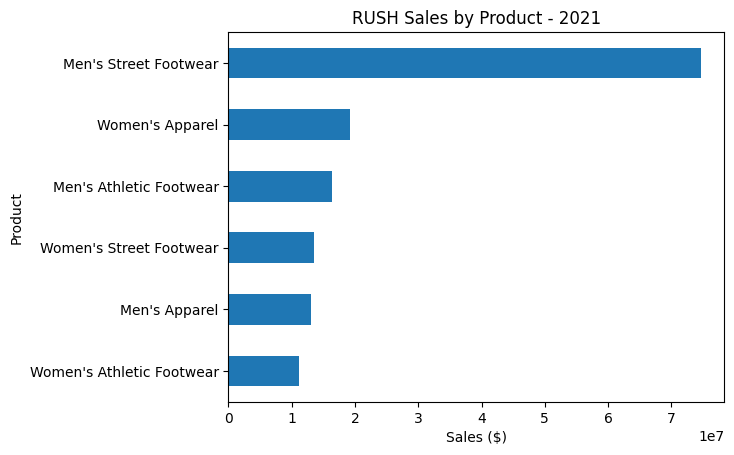

In [85]:
# visualize 2021 sales by product
product_sales.plot(kind='barh')

plt.title('RUSH Sales by Product - 2021')
plt.xlabel('Sales ($)')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.show()

In [86]:
# 2021 sales by sales method
method_sales = (sales_analysis[sales_analysis['YEAR'] == 2021].groupby('SALES_METHOD')['SALES_DOLLARS'].sum().sort_values(ascending=False))

display(method_sales)

,SALES_DOLLARS
SALES_METHOD,
Online,92411521.0
Outlet,29202860.0
In-store,26274075.0


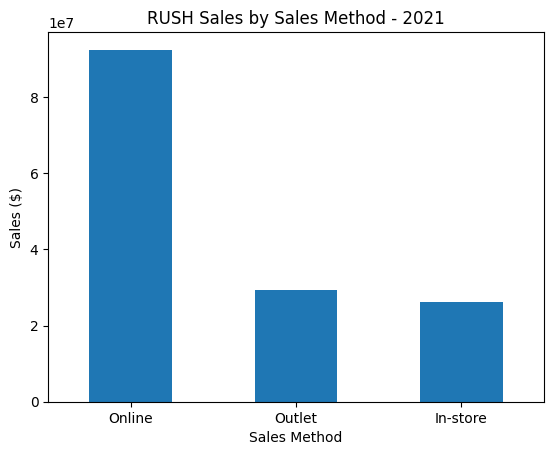

In [87]:
# visualize sales by sales method
method_sales.plot(kind='bar')

plt.title('RUSH Sales by Sales Method - 2021')
plt.xlabel('Sales Method')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.show()

In [88]:
# calculate the percentage of 2021 sales by sales method
method_percentage = (method_sales / method_sales.sum() * 100).round(1)

display(method_percentage)

,SALES_DOLLARS
SALES_METHOD,
Online,62.5
Outlet,19.7
In-store,17.8


In [89]:
# calculate monthly sales for 2021
monthly_sales = (sales_analysis[sales_analysis['YEAR'] == 2021].groupby('MONTH')['SALES_DOLLARS'].sum())

display(monthly_sales)

,SALES_DOLLARS
MONTH,
1,7432021.0
2,6123040.0
3,5220782.0
4,6498339.0
5,60542786.0
6,8718953.0
7,10368031.0
8,9651596.0
9,8037898.0


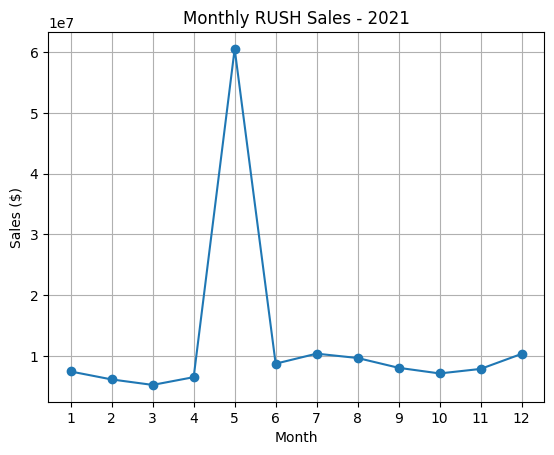

In [90]:
# visualize monthly sales trend
monthly_sales.plot(kind='line', marker='o')

plt.title('Monthly RUSH Sales - 2021')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(1, 13))
plt.grid()
plt.show()

In [91]:
# 2021 sales by region
region_sales = (sales_location[sales_location['YEAR'] == 2021].groupby('REGION')['SALES_DOLLARS'].sum().sort_values(ascending=False))

display(region_sales)

,SALES_DOLLARS
REGION,
Northeast,83216408.0
Midwest,24799271.0
West,20951383.0
Southeast,8738169.0
South,7902664.0


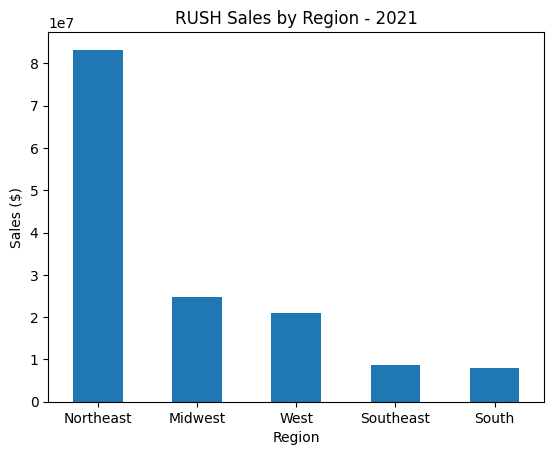

In [92]:
# visualize sales by region
region_sales.plot(kind='bar')

plt.title('RUSH Sales by Region - 2021')
plt.xlabel('Region')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.show()

In [93]:
# percentage of 2021 sales by region
region_percentage = (region_sales / region_sales.sum() * 100).round(1)

display(region_percentage)

,SALES_DOLLARS
REGION,
Northeast,57.2
Midwest,17.0
West,14.4
Southeast,6.0
South,5.4


In [94]:
# average operating margin by product in 2021
product_margin = (sales_analysis[sales_analysis['YEAR'] == 2021].groupby('PRODUCT_NAME')['OPERATING_MARGIN'].mean().sort_values(ascending=False))

display(product_margin)

,OPERATING_MARGIN
PRODUCT_NAME,
Women's Apparel,0.451591
Men's Street Footwear,0.445370
Women's Athletic Footwear,0.426288
Women's Street Footwear,0.412378
Men's Athletic Footwear,0.411334
Men's Apparel,0.409079


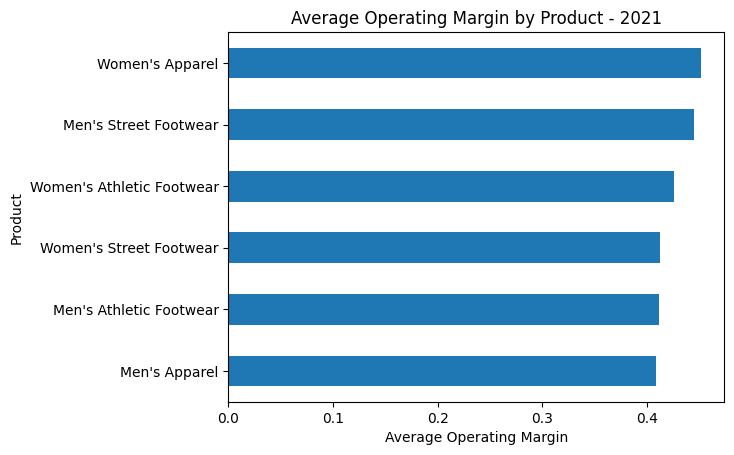

In [95]:
# visualize average operating margin by product
product_margin.plot(kind='barh')

plt.title('Average Operating Margin by Product - 2021')
plt.xlabel('Average Operating Margin')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.show()

In [96]:
# investigate Mays sales spike
may_sales = (sales_analysis[(sales_analysis['YEAR'] == 2021) &(sales_analysis['MONTH'] == 5)].groupby('PRODUCT_NAME')['SALES_DOLLARS'].sum().sort_values(ascending=False))

display(may_sales)

,SALES_DOLLARS
PRODUCT_NAME,
Men's Street Footwear,54033786.0
Women's Apparel,1839057.0
Men's Athletic Footwear,1348188.0
Women's Street Footwear,1195218.0
Men's Apparel,1141146.0
Women's Athletic Footwear,985391.0


In [97]:
# identify the largest individual sales records in May
may_orders = sales_analysis[(sales_analysis['YEAR'] == 2021) &(sales_analysis['MONTH'] == 5)].sort_values('SALES_DOLLARS', ascending=False)

display(may_orders[['ORDER_ID', 'PRODUCT_NAME', 'PRICE_PER_UNIT','UNITS_SOLD', 'SALES_DOLLARS', 'SALES_METHOD']].head(10))

,ORDER_ID,PRODUCT_NAME,PRICE_PER_UNIT,UNITS_SOLD,SALES_DOLLARS,SALES_METHOD
423,2536,Men's Street Footwear,99999.0,520.0,51999480.0,Online
387,2320,Men's Street Footwear,50.0,1045.0,52250.0,Online
1656,280,Men's Athletic Footwear,55.0,900.0,49500.0,Outlet
8207,1004,Women's Apparel,65.0,750.0,48750.0,Outlet
8427,2325,Women's Apparel,60.0,800.0,48000.0,Online
243,1456,Men's Street Footwear,55.0,870.0,47850.0,In-store
8087,284,Women's Apparel,65.0,725.0,47125.0,Outlet
1652,256,Men's Athletic Footwear,55.0,850.0,46750.0,Outlet
1653,262,Men's Athletic Footwear,55.0,850.0,46750.0,Outlet
8086,278,Women's Apparel,65.0,700.0,45500.0,Outlet


In [98]:
# investigate unusually large unit quantities in May
display(may_orders[['ORDER_ID', 'PRODUCT_NAME', 'UNITS_SOLD', 'PRICE_PER_UNIT', 'SALES_DOLLARS']].head(20))

,ORDER_ID,PRODUCT_NAME,UNITS_SOLD,PRICE_PER_UNIT,SALES_DOLLARS
423,2536,Men's Street Footwear,520.0,99999.0,51999480.0
387,2320,Men's Street Footwear,1045.0,50.0,52250.0
1656,280,Men's Athletic Footwear,900.0,55.0,49500.0
8207,1004,Women's Apparel,750.0,65.0,48750.0
8427,2325,Women's Apparel,800.0,60.0,48000.0
243,1456,Men's Street Footwear,870.0,55.0,47850.0
8087,284,Women's Apparel,725.0,65.0,47125.0
1652,256,Men's Athletic Footwear,850.0,55.0,46750.0
1653,262,Men's Athletic Footwear,850.0,55.0,46750.0
8086,278,Women's Apparel,700.0,65.0,45500.0
